In [1]:
########################################
# Packages
########################################
import warnings
import h5py as h5
import numpy as np
import pandas as pd
import multiprocessing as mp

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import math

import statistics

from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import binned_statistic
import scipy.stats.distributions as dist

import seaborn as sns

In [2]:
from data_processing import SHARKDataProcessor
processor = SHARKDataProcessor()

# Define subvolume IDs and HDF5 file paths
sv_list = np.arange(64)
# z=0 (201), z=0.5 (177), and z=1.0 (161)

sharkfiles_z0 = [f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/201/{sv}/galaxies.hdf5' for sv in sv_list]
sharkfiles_z05 = [f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/177/{sv}/galaxies.hdf5' for sv in sv_list]
sharkfiles_z1 = [f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/161/{sv}/galaxies.hdf5' for sv in sv_list]

#sharkfiles_z0 = [f'chandro_gomez_extracted_py/PSO_space4_L24HBT_SMFz0SMFz1/201/{sv}/galaxies.hdf5' for sv in sv_list]
#sharkfiles_z05 = [f'chandro_gomez_extracted_py/PSO_space4_L24HBT_SMFz0SMFz1/177/{sv}/galaxies.hdf5' for sv in sv_list]
#sharkfiles_z1 = [f'chandro_gomez_extracted_py/PSO_space4_L24HBT_SMFz0SMFz1/161/{sv}/galaxies.hdf5' for sv in sv_list]

# Output shark_csv dataframe
shark_csv_z0 = processor.process_all_subvolumes(sv_list, sharkfiles_z0)
shark_csv_z05 = processor.process_all_subvolumes(sv_list, sharkfiles_z05)
shark_csv_z1 = processor.process_all_subvolumes(sv_list, sharkfiles_z1)

print('z0',shark_csv_z0.shape)
print('z05',shark_csv_z05.shape)
print('z1',shark_csv_z1.shape)

z0 (802774, 32)
z05 (818144, 32)
z1 (817100, 32)


In [3]:
print(shark_csv_z05.head)

<bound method NDFrame.head of         ID_galaxy ID_subhalo     ID_subhalo_tree   ID_halo  sv  type  \
0             0_0        0_1   0_177000000000002       0_1   0     0   
1         0_40747        0_1   0_177000000000002       0_1   0     2   
2         0_24862        0_1   0_177000000000002       0_1   0     2   
3          0_4860        0_2   0_177000000220938       0_1   0     1   
4          0_2489        0_3   0_177000000190829       0_1   0     1   
...           ...        ...                 ...       ...  ..   ...   
818139   63_92329   63_41186  63_177000007457778  63_33778  63     0   
818140   63_66309   63_41246  63_177000005253508  63_33835  63     1   
818141   63_93073   63_41387  63_177000007483172  63_33972  63     0   
818142   63_97334   63_41388  63_177000007483578  63_33973  63     0   
818143  63_100013   63_46379  63_177000008112985  63_38906  63     0   

          Mhalo_host         Mhalo   Mstar_bulge    Mstar_disc  ...  \
0       4.344694e+13  4.019334e+13

In [30]:
########## STELLAR VS HALO CSV (Lagos 2024)

file_path = "Shark v2.0.csv"

WPD = pd.read_csv(file_path, header=None)
WPD.columns = ["Column1", "Column2"]
WPD = 10 ** WPD

# Filter out y-values (stellar mass) below 1e8
WPD = WPD[WPD["Column2"] >= 1e8]

# Sort by halo mass
WPD = WPD.sort_values(by="Column1").reset_index(drop=True)

print('Lagos 2024: ')
print(WPD.head())


########## STELLAR VS HALO CSV (Moster2013z0)

file_path1 = "Moster2013z0.csv"

Moster = pd.read_csv(file_path1, header=None)
Moster.columns = ["Column1", "Column2"]
Moster = 10 ** Moster

# Filter out stellar masses below 1e8
Moster = Moster[Moster["Column2"] >= 1e8]
# Filter out halo masses >= 1e15
Moster = Moster[Moster["Column1"] < 1e15]

# Sort by halo mass
Moster = Moster.sort_values(by="Column1").reset_index(drop=True)

print('Moster 2013: ')
print(Moster.head())


########## STELLAR VS HALO CSV (Moster2013z1)

file_path2 = "Moster13z1.csv"

MosterZ1 = pd.read_csv(file_path2, header=None)
MosterZ1.columns = ["Column1", "Column2"]
MosterZ1 = 10 ** MosterZ1

# Filter out stellar masses below 1e8
MosterZ1 = MosterZ1[MosterZ1["Column2"] >= 1e8]
# Filter out halo masses >= 1e15
MosterZ1 = MosterZ1[MosterZ1["Column1"] < 1e15]

# Sort by halo mass
MosterZ1 = MosterZ1.sort_values(by="Column1").reset_index(drop=True)

print('Moster 2013 (z=1): ')
print(MosterZ1.head())

########## STELLAR VS HALO CSV (KravstovZ0)

file_path2 = "Default Dataset.csv"

KravstovZ0 = pd.read_csv(file_path2, header=None)
KravstovZ0.columns = ["Column1", "Column2"]
KravstovZ0 = 10 ** KravstovZ0

# Filter out stellar masses below 1e8
KravstovZ0 = KravstovZ0[KravstovZ0["Column2"] >= 1e8]
# Filter out halo masses >= 1e15
KravstovZ0 = KravstovZ0[KravstovZ0["Column1"] < 1e15]

# Sort by halo mass
KravstovZ0 = KravstovZ0.sort_values(by="Column1").reset_index(drop=True)

print('Kravstov (z=0): ')
print(KravstovZ0.head())

#######################

########## BOOZI

file_path2 = "Z0_boozi.csv"

Z0_boozi = pd.read_csv(file_path2, header=None)
Z0_boozi.columns = ["Column1", "Column2"]
Z0_boozi = 10 ** Z0_boozi

# Filter out stellar masses below 1e8
Z0_boozi = Z0_boozi[Z0_boozi["Column2"] >= 1e8]
# Filter out halo masses >= 1e15
Z0_boozi = Z0_boozi[Z0_boozi["Column1"] < 1e15]

# Sort by halo mass
Z0_boozi = Z0_boozi.sort_values(by="Column1").reset_index(drop=True)

print('Z0_boozi (z=0): ')
print(Z0_boozi.head())

#######################

########## BOOZI

file_path2 = "Z05_boozi.csv"

Z05_boozi = pd.read_csv(file_path2, header=None)
Z05_boozi.columns = ["Column1", "Column2"]
Z05_boozi = 10 ** Z05_boozi

# Filter out stellar masses below 1e8
Z05_boozi = Z05_boozi[Z05_boozi["Column2"] >= 1e8]
# Filter out halo masses >= 1e15
Z05_boozi = Z05_boozi[Z05_boozi["Column1"] < 1e15]

# Sort by halo mass
Z05_boozi = Z05_boozi.sort_values(by="Column1").reset_index(drop=True)

print('Z05_boozi (z=0): ')
print(Z05_boozi.head())

#######################

########## BOOZI

file_path2 = "Z1_boozi.csv"

Z1_boozi = pd.read_csv(file_path2, header=None)
Z1_boozi.columns = ["Column1", "Column2"]
Z1_boozi = 10 ** Z1_boozi

# Filter out stellar masses below 1e8
Z1_boozi = Z1_boozi[Z1_boozi["Column2"] >= 1e8]
# Filter out halo masses >= 1e15
Z1_boozi = Z1_boozi[Z1_boozi["Column1"] < 1e15]

# Sort by halo mass
Z1_boozi = Z1_boozi.sort_values(by="Column1").reset_index(drop=True)

print('Z1_boozi (z=0): ')
print(Z1_boozi.head())

#######################

#plt.plot(WPD["Column1"], WPD["Column2"], color='orange',label='Lagos 2024')
#plt.plot(Moster["Column1"], Moster["Column2"], color='orange', label='Moster 2013')
#plt.plot(MosterZ1["Column1"], MosterZ1["Column2"], color='orange')

#axs[0,0].plot(WPD["Column1"], WPD["Column2"], color='blue',label='Lagos 2024')
#axs[0,0].plot(Moster["Column1"], Moster["Column2"], color='orange', label='Moster 2013')
#axs[2,0].plot(MosterZ1["Column1"], MosterZ1["Column2"], color='orange')


Lagos 2024: 
        Column1       Column2
0  6.491265e+10  1.078365e+08
1  7.293825e+10  1.334531e+08
2  8.085471e+10  1.642698e+08
3  9.217028e+10  2.015153e+08
4  1.039324e+11  2.540479e+08
Moster 2013: 
        Column1       Column2
0  4.500971e+10  1.138695e+08
1  4.927407e+10  1.432941e+08
2  5.464621e+10  1.829905e+08
3  5.935448e+10  2.216411e+08
4  6.465800e+10  2.605926e+08
Moster 2013 (z=1): 
        Column1       Column2
0  6.588153e+10  1.118976e+08
1  7.999905e+10  1.640770e+08
2  8.814716e+10  2.089550e+08
3  9.712518e+10  2.661079e+08
4  1.070286e+11  3.190017e+08
Kravstov (z=0): 
        Column1       Column2
0  4.023187e+10  1.135534e+08
1  4.545422e+10  1.443033e+08
2  5.076657e+10  1.763758e+08
3  5.622698e+10  2.147971e+08
4  6.269329e+10  2.600762e+08
Z0_boozi (z=0): 
        Column1       Column2
0  7.301009e+10  2.399960e+08
1  8.273780e+10  3.260180e+08
2  8.897983e+10  3.877783e+08
3  9.569278e+10  4.624509e+08
4  1.042070e+11  5.554952e+08
Z05_boozi (z=0): 
 

z0 Min=  9.94713017270628 Max=  15.2323102444803
z0.5 Min=  9.877494238095126 Max=  14.906068846556208
z1 Min=  9.97816437437632 Max=  14.70542160494771


<function matplotlib.pyplot.show(close=None, block=None)>

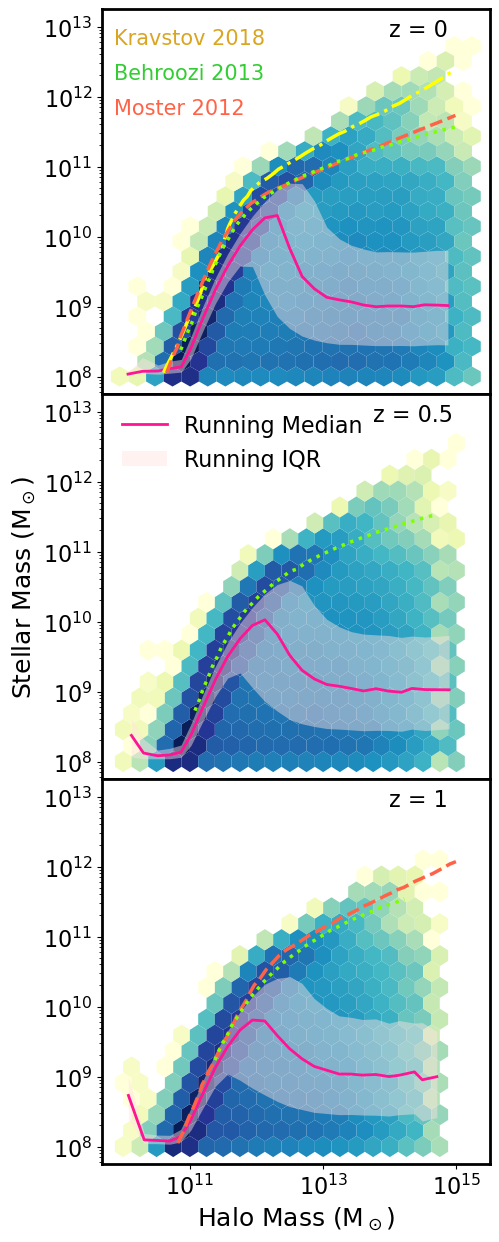

In [210]:
########################################
# Stellar Mass vs. Halo Mass WITH binned medians
########################################

fig, axs = plt.subplots(3, 1, figsize=(5,15), sharey=True , sharex=True)
fig.subplots_adjust(hspace=0)

########################################
# Column 1: z=0
########################################
hb_lagos = axs[0].hexbin(shark_csv_z0['Mhalo_host'], shark_csv_z0['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                )

print("z0 Min= ", np.min(np.log10(shark_csv_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_z0['Mhalo_host'], shark_csv_z0['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_z0['Mhalo_host'][(shark_csv_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_z0['Mhalo_host'], shark_csv_z0['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_z0['Mhalo_host'], shark_csv_z0['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')



########################################
# Column 2: z=0.5
########################################
hb_lagos = axs[1].hexbin(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

axs[1].set_ylabel(r'Stellar Mass (M$_\odot$)', fontsize=18)

print("z0.5 Min= ", np.min(np.log10(shark_csv_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_z05['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_z05['Mhalo_host'][(shark_csv_z05['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_z05['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

axs[1].legend(loc='upper left', fontsize=16, frameon=False)

########################################
# Column 3: z=1
########################################
hb_lagos = axs[2].hexbin(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("z1 Min= ", np.min(np.log10(shark_csv_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_z1['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_z1['Mhalo_host'][(shark_csv_z1['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_z1['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[2].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[2].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

axs[2].set_xlabel(r'Halo Mass (M$_\odot$)', fontsize=18)

######################
# Misc. Settings
######################

axs[0].text(0.74, 0.93, 'z = 0', transform=axs[0].transAxes, fontsize=16)
axs[1].text(0.70, 0.93, 'z = 0.5', transform=axs[1].transAxes, fontsize=16)
axs[2].text(0.74, 0.93, 'z = 1', transform=axs[2].transAxes, fontsize=16)

axs[0].plot(KravstovZ0["Column1"], KravstovZ0["Column2"], 
            color='yellow', 
            label='Kravstov 2018',
            linewidth=2.5,
            alpha=1.0,
            linestyle='-.',
           )

axs[2].plot(MosterZ1["Column1"], MosterZ1["Column2"], 
            color='tomato', 
            label='Moster 2024',
            linewidth=2.5,
            alpha=1.0,
            linestyle='--',
           )

axs[0].plot(Moster["Column1"], Moster["Column2"], 
            color='tomato', 
            linewidth=2.5,
            alpha=1.0,
            linestyle='--',
           )

axs[0].plot(Z0_boozi["Column1"], Z0_boozi["Column2"], 
            color='chartreuse', 
            label='Behroozi 2013',
            linewidth=2.5,
            alpha=1.0,
            linestyle=':',
           )

axs[1].plot(Z05_boozi["Column1"], Z05_boozi["Column2"], 
            color='chartreuse', 
            linewidth=2.5,
            alpha=1.0,
            linestyle=':',
           )

axs[2].plot(Z1_boozi["Column1"], Z1_boozi["Column2"], 
            color='chartreuse', 
            linewidth=2.5,
            alpha=1.0,
            linestyle=':',
           )

import matplotlib.patheffects as path_effects
# Floating label for Kravstov 2018
kstov = axs[0].text(0.03, 0.95, 'Kravstov 2018',
                    fontsize=15, color='goldenrod', rotation=0,
                    transform=axs[0].transAxes, verticalalignment='top')
#kstov.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])

# Floating label for Behroozi 2013
boozi = axs[0].text(0.03, 0.86, 'Behroozi 2013',
                    fontsize=15, color='limegreen', rotation=0,
                    transform=axs[0].transAxes, verticalalignment='top')
#boozi.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])

# Floating label for Moster 2012
mosterTXT = axs[0].text(0.03, 0.77, 'Moster 2012',
                        fontsize=15, color='tomato', rotation=0,
                        transform=axs[0].transAxes, verticalalignment='top')
#mosterTXT.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

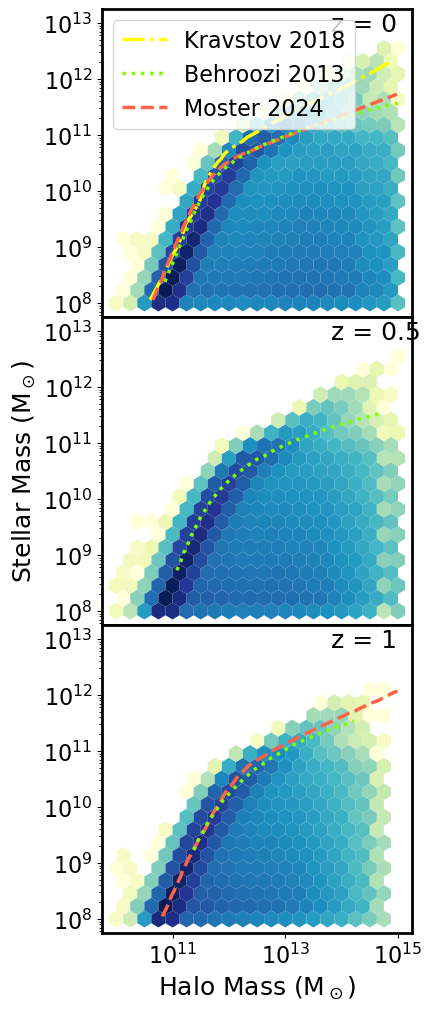

In [80]:
########################################
# Stellar Mass vs. Halo Mass NO binned medians
########################################

fig, axs = plt.subplots(3, 1, figsize=(4, 12), sharey=True , sharex=True)
fig.subplots_adjust(hspace=0)

########################################
# Column 1: z=0
########################################
hb_z0 = axs[0].hexbin(shark_csv_z0['Mhalo_host'], shark_csv_z0['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

########################################
# Column 2: z=0.5
########################################
hb_z05 = axs[1].hexbin(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

axs[1].set_ylabel(r'Stellar Mass (M$_\odot$)', fontsize=18)

########################################
# Column 3: z=1
########################################
hb_z1 = axs[2].hexbin(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))


axs[2].set_xlabel(r'Halo Mass (M$_\odot$)', fontsize=18)

######################
# Misc. Settings
######################

axs[0].text(0.74, 0.93, 'z = 0', transform=axs[0].transAxes, fontsize=18)
axs[1].text(0.74, 0.93, 'z = 0.5', transform=axs[1].transAxes, fontsize=18)
axs[2].text(0.74, 0.93, 'z = 1', transform=axs[2].transAxes, fontsize=18)

axs[0].plot(KravstovZ0["Column1"], KravstovZ0["Column2"], 
            color='yellow', 
            label='Kravstov 2018',
            linewidth=2.5,
            alpha=1.0,
            linestyle='-.',
           )

axs[2].plot(MosterZ1["Column1"], MosterZ1["Column2"], 
            color='tomato', 
            label='Moster 2024',
            linewidth=2.5,
            alpha=1.0,
            linestyle='--',
           )

axs[0].plot(Moster["Column1"], Moster["Column2"], 
            color='tomato', 
            linewidth=2.5,
            alpha=1.0,
            linestyle='--',
           )

axs[0].plot(Z0_boozi["Column1"], Z0_boozi["Column2"], 
            color='chartreuse', 
            label='Behroozi 2013',
            linewidth=2.5,
            alpha=1.0,
            linestyle=':',
           )

axs[1].plot(Z05_boozi["Column1"], Z05_boozi["Column2"], 
            color='chartreuse', 
            linewidth=2.5,
            alpha=1.0,
            linestyle=':',
           )

axs[2].plot(Z1_boozi["Column1"], Z1_boozi["Column2"], 
            color='chartreuse', 
            linewidth=2.5,
            alpha=1.0,
            linestyle=':',
           )

# Collect all handles/labels from every subplot
handles, labels = [], []
for ax in axs:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l

# Only keep unique labels (optional cleanup)
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

# Place the legend in the top subplot or figure-wide
axs[0].legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=16)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

In [7]:
# Settings to filter centrals and satellites
shark_csv_centrals_z0 = shark_csv_z0[(shark_csv_z0['type'] == 0)] ######## Centrals only
shark_csv_satellites_z0 = shark_csv_z0[(shark_csv_z0['type'] == 1)] ######## Satellites only

shark_csv_centrals_z05 = shark_csv_z05[(shark_csv_z05['type'] == 0)] ######## Centrals only
shark_csv_satellites_z05 = shark_csv_z05[(shark_csv_z05['type'] == 1)] ######## Satellites only

shark_csv_centrals_z1 = shark_csv_z1[(shark_csv_z1['type'] == 0)] ######## Centrals only
shark_csv_satellites_z1 = shark_csv_z1[(shark_csv_z1['type'] == 1)] ######## Satellites only

z0 Min=  9.94713017270628 Max=  15.2323102444803
z0.5 Min=  9.877494238095126 Max=  14.906068846556208
z1 Min=  9.97816437437632 Max=  14.70542160494771
z0 sat Min=  10.568844862565543 Max=  15.2323102444803
z0.5 sat Min=  10.616136943035965 Max=  14.906068846556208
z1 sat Min=  10.661894452728644 Max=  14.70542160494771


<function matplotlib.pyplot.show(close=None, block=None)>

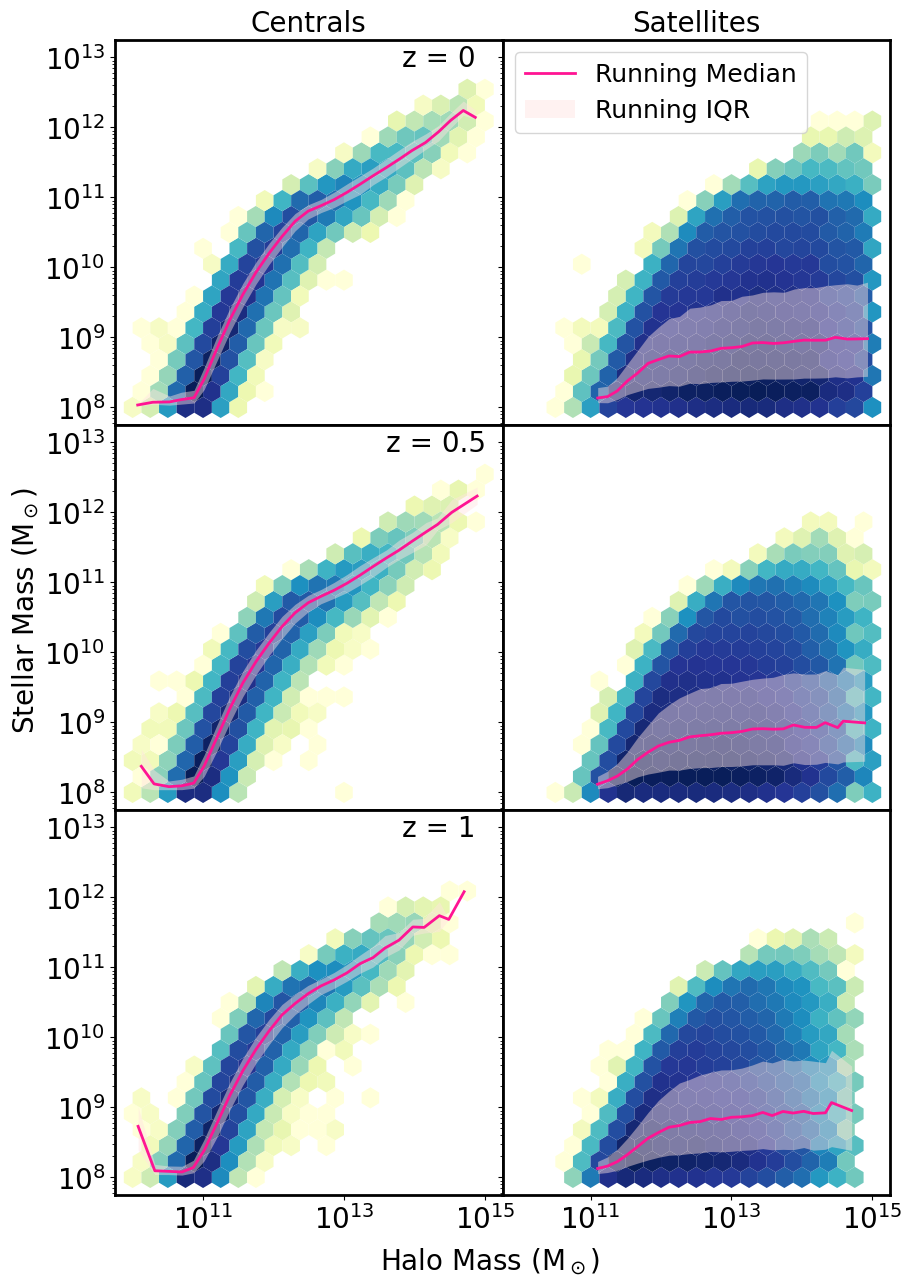

In [126]:
########################################
# Stellar Mass vs. Halo Mass
########################################

fig, axs = plt.subplots(3, 2, figsize=(10, 15), sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

########################################
# axs[0,0]: z=0, centrals
########################################
hb_lagos = axs[0,0].hexbin(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("z0 Min= ", np.min(np.log10(shark_csv_centrals_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z0['Mhalo_host'][(shark_csv_centrals_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[0,1]: z=0.5
########################################
hb_lagos = axs[1,0].hexbin(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("z0.5 Min= ", np.min(np.log10(shark_csv_centrals_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z05['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z05['Mhalo_host'][(shark_csv_centrals_z05['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z05['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[1,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[1,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[0,2]: z=1
########################################
hb_lagos = axs[2,0].hexbin(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("z1 Min= ", np.min(np.log10(shark_csv_centrals_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z1['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z1['Mhalo_host'][(shark_csv_centrals_z1['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z1['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[2,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[2,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[1,0]: z=0, satellites
########################################
hb_lagos = axs[0,1].hexbin(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("z0 sat Min= ", np.min(np.log10(shark_csv_satellites_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z0['Mhalo_host'][(shark_csv_satellites_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axsaxs[1,1]: z=0.5 Satellites
########################################
hb_lagos = axs[1,1].hexbin(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("z0.5 sat Min= ", np.min(np.log10(shark_csv_satellites_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z05['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z05['Mhalo_host'][(shark_csv_satellites_z05['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z05['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[1,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[1,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[1,2]: z=1
########################################
hb_lagos = axs[2,1].hexbin(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("z1 sat Min= ", np.min(np.log10(shark_csv_satellites_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z1['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z1['Mhalo_host'][(shark_csv_satellites_z1['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z1['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[2,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink')
axs[2,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0)

######################
# Misc. Settings
######################
fig.text(0.50, 0.06, r'Halo Mass (M$_\odot$)', ha='center', fontsize=20)
fig.text(0.02, 0.50, r'Stellar Mass (M$_\odot$)', va='center', rotation='vertical', fontsize=20)


axs[0,0].text(0.74, 0.93, 'z = 0', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(0.70, 0.93, 'z = 0.5', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(0.74, 0.93, 'z = 1', transform=axs[2,0].transAxes, fontsize=20)

axs[0,0].set_title('Centrals',fontsize=20)
axs[0,1].set_title('Satellites', fontsize=20)

# Column 1: Legend
axs[0,1].legend(loc='upper left', fontsize=18)

# Set global tick label size and spine width for all subplots
for ax in axs.flatten():
    ax.tick_params(axis='both', labelsize=20)  # Adjust fontsize here
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# Hide x-axis tick labels for top and middle rows only
for ax in axs[0, :]:  # Top row
    ax.set_xticklabels([])
for ax in axs[1, :]:  # Middle row
    ax.set_xticklabels([])

plt.show

In [26]:
# Define a list of all filtered DataFrames
filtered_dfs = [
    shark_csv_centrals_z0, shark_csv_satellites_z0,
    shark_csv_centrals_z05, shark_csv_satellites_z05,
    shark_csv_centrals_z1, shark_csv_satellites_z1
]

# Add SHMR = Mstar_all / Mhalo_host to each
for df in filtered_dfs:
    df['SHMR'] = df['Mstar_all'] / df['Mhalo_host']

C:\Users\Jonah\AppData\Local\Temp\ipykernel_36420\3684140901.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SHMR'] = df['Mstar_all'] / df['Mhalo_host']


In [164]:
########## SHMR CSV (BEHROOZI 2019 UniverseMachine)
file_path2 = "Behroozi.csv"

SHMRline = pd.read_csv(file_path2, header=None)
SHMRline.columns = ["Column1", "Column2"]
SHMRline = 10 ** SHMRline

SHMRline = SHMRline.sort_values(by="Column1").reset_index(drop=True)

########## SHMR CSV (BEHROOZI 2013)
file_path3 = "BH2013.csv"

SHMRline2 = pd.read_csv(file_path3, header=None)
SHMRline2.columns = ["Column1", "Column2"]
SHMRline2 = 10 ** SHMRline2

SHMRline2 = SHMRline2.sort_values(by="Column1").reset_index(drop=True)

z0 Min=  9.94713017270628 Max=  15.2323102444803
Halo Mass:  10.072068876763602 SHMR:  -2.0329341622634565
Halo Mass:  10.286618406317833 SHMR:  -2.2562765920948578
Halo Mass:  10.5243665584262 SHMR:  -2.4332946524985046
Halo Mass:  10.69185763784208 SHMR:  -2.5599392891574917
Halo Mass:  10.87179226311831 SHMR:  -2.7234653383066036
Halo Mass:  11.015453464795284 SHMR:  -2.6063688812406824
Halo Mass:  11.195194287726252 SHMR:  -2.3552547828777537
Halo Mass:  11.38087035598542 SHMR:  -2.125786410407925
Halo Mass:  11.564984439720588 SHMR:  -1.9509474634026953
Halo Mass:  11.750789538593436 SHMR:  -1.8214574927057858
Halo Mass:  11.936217248777291 SHMR:  -1.7342446882524374
Halo Mass:  12.120748021230849 SHMR:  -1.6782567663344736
Halo Mass:  12.305840329514623 SHMR:  -1.6497087478089398
Halo Mass:  12.490761398328319 SHMR:  -1.692812340349326
Halo Mass:  12.676819782807558 SHMR:  -1.7953878871983526
Halo Mass:  12.859411289851993 SHMR:  -1.893367831248179
Halo Mass:  13.045068373169865 

<function matplotlib.pyplot.show(close=None, block=None)>

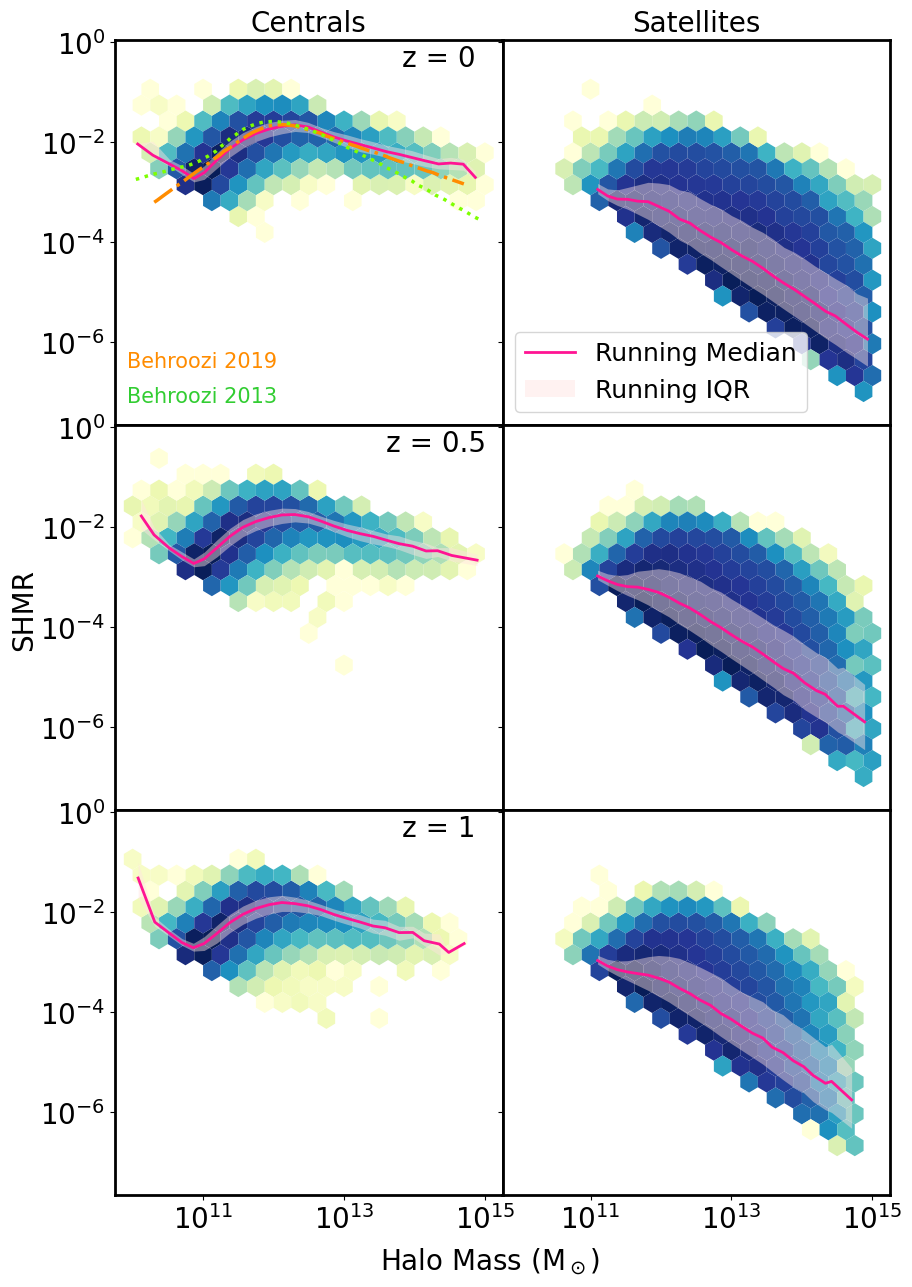

In [234]:
########################################
# SHMR
########################################

fig, axs = plt.subplots(3, 2, figsize=(10, 15), sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

########################################
# axs[0,0]: z=0, centrals
########################################
hb_lagos = axs[0,0].hexbin(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(5e-1), np.log10(5e-8)))

print("z0 Min= ", np.min(np.log10(shark_csv_centrals_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z0['Mhalo_host'][(shark_csv_centrals_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

for i in range(len(bin_medians_lagos)):
    print("Halo Mass: ", np.log10(xVals_lagos[i]), "SHMR: ", np.log10(bin_medians_lagos[i]))

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[0,1]: z=0.5
########################################
hb_lagos = axs[1,0].hexbin(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['SHMR'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(5e-1), np.log10(5e-8)))

print("z0.5 Min= ", np.min(np.log10(shark_csv_centrals_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z05['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['SHMR'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic
print(bin_medians_lagos)

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z05['Mhalo_host'][(shark_csv_centrals_z05['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z05['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

for i in range(len(bin_medians_lagos)):
    print("Halo Mass: ", np.log10(xVals_lagos[i]), "SHMR: ", np.log10(bin_medians_lagos[i]))

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['SHMR'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['SHMR'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[1,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[1,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[0,2]: z=1
########################################
hb_lagos = axs[2,0].hexbin(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['SHMR'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(5e-1), np.log10(5e-8)))

print("z1 Min= ", np.min(np.log10(shark_csv_centrals_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z1['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['SHMR'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic
print(bin_medians_lagos)

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z1['Mhalo_host'][(shark_csv_centrals_z1['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z1['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

for i in range(len(bin_medians_lagos)):
    print("Halo Mass: ", np.log10(xVals_lagos[i]), "SHMR: ", np.log10(bin_medians_lagos[i]))

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['SHMR'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['SHMR'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[2,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[2,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[1,0]: z=0, satellites
########################################
hb_lagos = axs[0,1].hexbin(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['SHMR'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(5e-1), np.log10(5e-8)))

print("z0 sat Min= ", np.min(np.log10(shark_csv_satellites_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['SHMR'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z0['Mhalo_host'][(shark_csv_satellites_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['SHMR'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['SHMR'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axsaxs[1,1]: z=0.5 Satellites
########################################
hb_lagos = axs[1,1].hexbin(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['SHMR'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(5e-1), np.log10(5e-8)))

print("z0.5 sat Min= ", np.min(np.log10(shark_csv_satellites_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z05['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['SHMR'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z05['Mhalo_host'][(shark_csv_satellites_z05['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z05['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['SHMR'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['SHMR'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[1,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[1,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[1,2]: z=1
########################################
hb_lagos = axs[2,1].hexbin(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['SHMR'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(5e-1), np.log10(5e-8)))

print("z1 sat Min= ", np.min(np.log10(shark_csv_satellites_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z1['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['SHMR'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z1['Mhalo_host'][(shark_csv_satellites_z1['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z1['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['SHMR'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['SHMR'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[2,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink')
axs[2,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0)

######################
# Misc. Settings
######################
fig.text(0.50, 0.06, r'Halo Mass (M$_\odot$)', ha='center', fontsize=20)
fig.text(0.02, 0.50, r'SHMR', va='center', rotation='vertical', fontsize=20)


axs[0,0].text(0.74, 0.93, 'z = 0', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(0.70, 0.93, 'z = 0.5', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(0.74, 0.93, 'z = 1', transform=axs[2,0].transAxes, fontsize=20)

axs[0,0].set_title('Centrals',fontsize=20)
axs[0,1].set_title('Satellites', fontsize=20)

# Column 1: Legend
axs[0,1].legend(loc='lower left', fontsize=18)

axs[0,0].plot(SHMRline["Column1"], SHMRline["Column2"], color='darkorange', linewidth=2.5, linestyle='-.') #BEHROOZI 2019
axs[0,0].plot(SHMRline2["Column1"], SHMRline2["Column2"], color='chartreuse', linewidth=2.5, linestyle=':') #BEHROOZI 2013

# Floating label for Behroozi 2013
boozi13 = axs[0,0].text(0.03, 0.1, 'Behroozi 2013',
                    fontsize=15, color='limegreen', rotation=0,
                    transform=axs[0,0].transAxes, verticalalignment='top')
boozi19 = axs[0,0].text(0.03, 0.19, 'Behroozi 2019',
                    fontsize=15, color='darkorange', rotation=0,
                    transform=axs[0,0].transAxes, verticalalignment='top')

# Set global tick label size and spine width for all subplots
for ax in axs.flatten():
    ax.tick_params(axis='both', labelsize=20)  # Adjust fontsize here
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# Hide x-axis tick labels for top and middle rows only
for ax in axs[0, :]:  # Top row
    ax.set_xticklabels([])
for ax in axs[1, :]:  # Middle row
    ax.set_xticklabels([])

plt.show

In [11]:
# Define a list of all filtered DataFrames
filtered_dfs = [
    shark_csv_centrals_z0, shark_csv_satellites_z0,
    shark_csv_centrals_z05, shark_csv_satellites_z05,
    shark_csv_centrals_z1, shark_csv_satellites_z1
]

# Add SHMR = Mstar_all / Mhalo_host to each
for df in filtered_dfs:
    df['cold_gas_fraction'] = df['Mcoldgas_all'] / (df['Mcoldgas_all'] + df['Mhotgas'] + df['Mstar_all'])

C:\Users\Jonah\AppData\Local\Temp\ipykernel_36420\2605071466.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cold_gas_fraction'] = df['Mcoldgas_all'] / (df['Mcoldgas_all'] + df['Mhotgas'] + df['Mstar_all'])
C:\Users\Jonah\AppData\Local\Temp\ipykernel_36420\2605071466.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cold_gas_fraction'] = df['Mcoldgas_all'] / (df['Mcoldgas_all'] + df['Mhotgas'] + df['Mstar_all'])
C:\Users\Jonah\AppData\Local\Temp\ipykernel_36420\2605071466.py:10: SettingWithC

z0 Min=  9.94713017270628 Max=  15.2323102444803
z0.5 Min=  9.877494238095126 Max=  14.906068846556208
z1 Min=  9.97816437437632 Max=  14.70542160494771
z0 sat Min=  10.568844862565543 Max=  15.2323102444803
z0.5 sat Min=  10.616136943035965 Max=  14.906068846556208
z1 sat Min=  10.661894452728644 Max=  14.70542160494771


<function matplotlib.pyplot.show(close=None, block=None)>

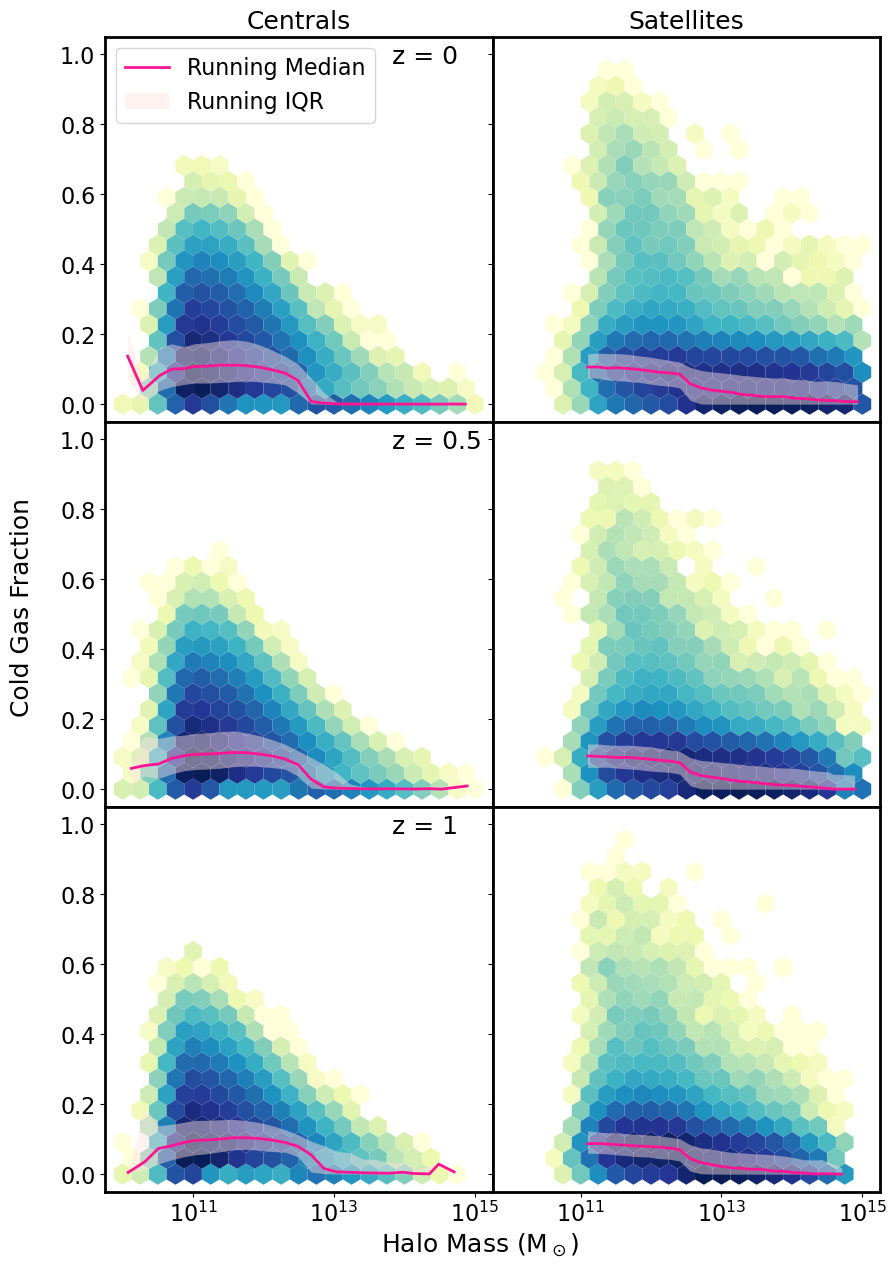

In [12]:
########################################
# cold_gas_fraction
########################################

fig, axs = plt.subplots(3, 2, figsize=(10, 15), sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

########################################
# axs[0,0]: z=0, centrals
########################################
hb_lagos = axs[0,0].hexbin(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['cold_gas_fraction'], gridsize=20, xscale='log', yscale='linear',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), 0,1))

print("z0 Min= ", np.min(np.log10(shark_csv_centrals_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['cold_gas_fraction'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z0['Mhalo_host'][(shark_csv_centrals_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['cold_gas_fraction'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['cold_gas_fraction'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[0,1]: z=0.5
########################################
hb_lagos = axs[1,0].hexbin(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['cold_gas_fraction'], gridsize=20, xscale='log', yscale='linear',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), 0,1))

print("z0.5 Min= ", np.min(np.log10(shark_csv_centrals_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z05['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['cold_gas_fraction'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z05['Mhalo_host'][(shark_csv_centrals_z05['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z05['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['cold_gas_fraction'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['cold_gas_fraction'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[1,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[1,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[0,2]: z=1
########################################
hb_lagos = axs[2,0].hexbin(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['cold_gas_fraction'], gridsize=20, xscale='log', yscale='linear',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), 0,1))

print("z1 Min= ", np.min(np.log10(shark_csv_centrals_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z1['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['cold_gas_fraction'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z1['Mhalo_host'][(shark_csv_centrals_z1['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z1['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['cold_gas_fraction'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['cold_gas_fraction'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[2,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[2,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[1,0]: z=0, satellites
########################################
hb_lagos = axs[0,1].hexbin(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['cold_gas_fraction'], gridsize=20, xscale='log', yscale='linear',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), 0,1))

print("z0 sat Min= ", np.min(np.log10(shark_csv_satellites_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['cold_gas_fraction'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z0['Mhalo_host'][(shark_csv_satellites_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['cold_gas_fraction'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z0['Mhalo_host'], shark_csv_satellites_z0['cold_gas_fraction'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axsaxs[1,1]: z=0.5 Satellites
########################################
hb_lagos = axs[1,1].hexbin(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['cold_gas_fraction'], gridsize=20, xscale='log', yscale='linear',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), 0,1))

print("z0.5 sat Min= ", np.min(np.log10(shark_csv_satellites_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z05['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['cold_gas_fraction'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z05['Mhalo_host'][(shark_csv_satellites_z05['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z05['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['cold_gas_fraction'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['cold_gas_fraction'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[1,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[1,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

########################################
# axs[1,2]: z=1
########################################
hb_lagos = axs[2,1].hexbin(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['cold_gas_fraction'], gridsize=20, xscale='log', yscale='linear',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), 0,1))

print("z1 sat Min= ", np.min(np.log10(shark_csv_satellites_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_satellites_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_z1['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['cold_gas_fraction'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_z1['Mhalo_host'][(shark_csv_satellites_z1['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_z1['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['cold_gas_fraction'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['cold_gas_fraction'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[2,1].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink')
axs[2,1].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0)

######################
# Misc. Settings
######################
fig.text(0.5, 0.07, r'Halo Mass (M$_\odot$)', ha='center', fontsize=18)
fig.text(0.03, 0.5, r'Cold Gas Fraction', va='center', rotation='vertical', fontsize=18)


axs[0,0].text(0.74, 0.93, 'z = 0', transform=axs[0,0].transAxes, fontsize=18)
axs[1,0].text(0.74, 0.93, 'z = 0.5', transform=axs[1,0].transAxes, fontsize=18)
axs[2,0].text(0.74, 0.93, 'z = 1', transform=axs[2,0].transAxes, fontsize=18)

axs[0,0].set_title('Centrals',fontsize=18)
axs[0,1].set_title('Satellites', fontsize=18)

# Column 1: Legend
axs[0,0].legend(loc='upper left', fontsize=16)

# Remove x-axis tick labels from the first row
for ax in axs[0]:  # axs[0] is the first row
    ax.set_xticklabels([])
    ax.set_xlabel('')

for ax in axs.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)

# Hide x-axis tick labels for top and middle rows
for row in axs[:-1]:
    for ax in row:
        ax.set_xticklabels([])

plt.show

z0 Min=  9.94713017270628 Max=  15.2323102444803


Text(0, 0.5, 'SHMR')

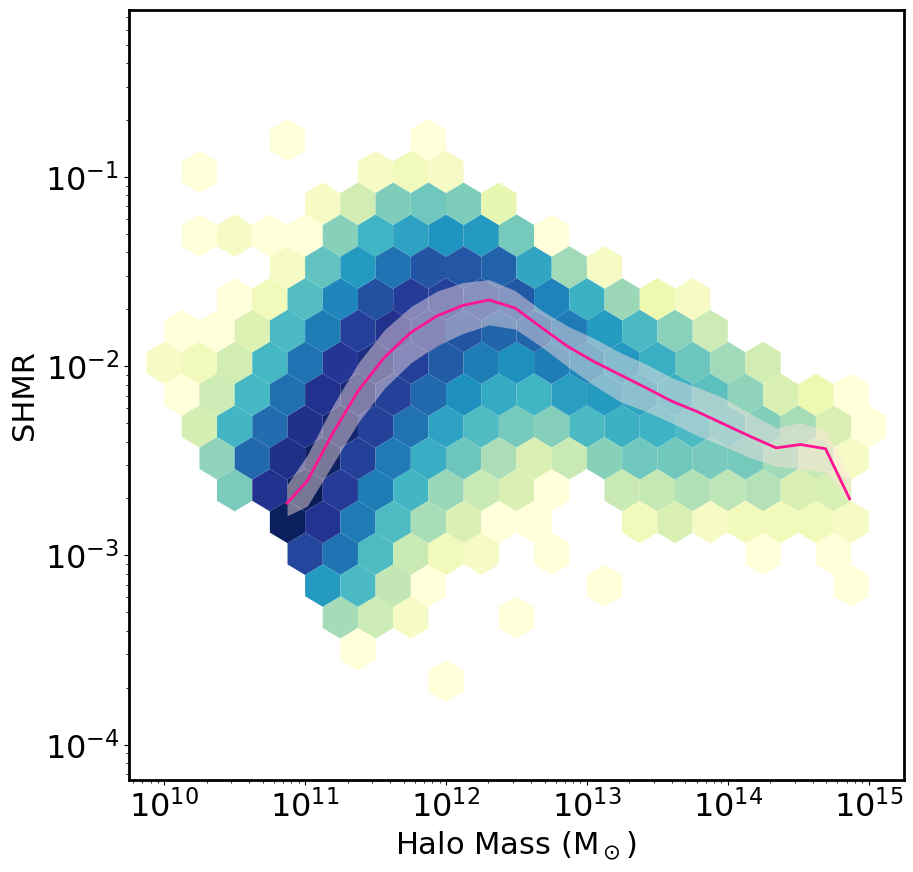

In [218]:
fig, ax = plt.subplots(figsize=(10, 10))

########################################
# axs[0,0]: z=0, centrals
########################################
hb_lagos = plt.hexbin(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(5e-1), np.log10(1e-4)))

print("z0 Min= ", np.min(np.log10(shark_csv_centrals_z0['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_centrals_z0['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_z0['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_z0['Mhalo_host'][(shark_csv_centrals_z0['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_z0['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_z0['Mhalo_host'], shark_csv_centrals_z0['SHMR'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

# Filter points where x >= 1e11
mask = xVals_lagos >= 5e10
xVals_lagos, bin_medians_lagos, p25_lagos, p75_lagos = xVals_lagos[mask], bin_medians_lagos[mask], p25_lagos[mask], p75_lagos[mask]

plt.plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
plt.fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

# Set spine width
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Set tick label sizes
ax.tick_params(axis='both', which='major', labelsize=23)

# Optional: Add labels and legend
ax.set_xlabel(r'Halo Mass (M$_\odot$)', fontsize=22)
ax.set_ylabel('SHMR', fontsize=22)